# Regresión Lineal

**Universidad de los Andes — Minería de Datos**  
**Semana 2 — Aprendizaje Supervisado — Modelos Lineales**

---

## Objetivos de aprendizaje

- Comprender los fundamentos del aprendizaje supervisado y los modelos lineales.
- Implementar y evaluar modelos de regresión lineal simple y múltiple utilizando scikit-learn.
- Aplicar regresión polinómica para capturar relaciones no lineales entre variables.
- Evaluar los supuestos del modelo de regresión lineal y comparar el rendimiento de distintos modelos.

## 1. Aprendizaje Supervisado — Modelos Lineales

## 2. Regresión Lineal Simple

La regresión lineal simple es una técnica que permite modelar la relación entre una variable dependiente y una única variable independiente. Es útil para identificar tendencias y hacer predicciones básicas basadas en la relación observada entre estas dos variables. Esta técnica es adecuada cuando hay una única variable que se cree que influye en la variable objetivo, y el objetivo es entender y predecir esa relación. Sin embargo, en muchos casos del mundo real, el comportamiento de una variable dependiente está influenciado por múltiples factores, por esta razón el ejemplo de este notebook estara centrado en una ejercicio de Regresión Multiple.










## 3. Regresión Lineal Múltiple

La regresión lineal múltiple es una extensión del modelo de regresión lineal simple que permite incluir múltiples variables independientes para predecir el valor de una variable dependiente. Esta técnica es especialmente útil cuando queremos modelar relaciones complejas y capturar la influencia de varios factores al mismo tiempo.

En este notebook, se va a trabajar con un ejemplo práctico de regresión lineal múltiple utilizando el conjunto de datos de **precios de viviendas de Ames**.

Durante el desarrollo de este ejemplo, se realizaran las siguientes actividades:


1. **Importación de Librerías y Carga del Conjunto de Datos**: Se comienza importando las librerías necesarias para el análisis y cargando el conjunto de datos de viviendas de Ames.

2. **Exploración y Transformación de Datos**: Se realiza una exploración inicial de los datos para identificar las variables relevantes y entender la estructura del dataset. Luego, se tratan los duplicados y Na.

3. **Asociación Variables Numericas y Categoricas**: Se utiliza la matriz de correlacion para las variables numericas y la V de Kramers para evaluar la asociación entre variables categóricas y la variable objetivo, lo cual ayuda en la selección de variables relevantes.

4. **División de Datos en Conjuntos de Entrenamiento y Prueba**: Se dividen los datos en conjuntos de entrenamiento y prueba para poder entrenar y validar los modelos de manera efectiva.

5. **Pipeline para Procesamiento de Variables**: Se construye un pipeline para el procesamiento multivariado de las variables. Este pipeline incluye el manejo de valores faltantes, transformación de variables categóricas y estandarización de variables numéricas.

6. **Evaluación de la Multicolinealidad**: Se calcula el Variance Inflation Factor (VIF) para identificar la presencia de multicolinealidad entre las variables independientes y se seleccionan las variables con bajo VIF

7. **Construcción y Evaluación del Modelo de Regresión Lineal Múltiple**: Se ajusta el modelo de regresión lineal múltiple utilizando las variables seleccionadas. Se evalúa el rendimiento del modelo mediante métricas como el Coeficiente de Determinación (R²).

8. **Incorporación de Términos Polinómicos**: Se añade un término polinómico de grado 2 al modelo para capturar relaciones no lineales. El modelo polinómico es entrenado y se comparan los resultados con el modelo de regresión lineal múltiple.

9. **Evaluación de Supuestos del Modelo**: Se verifican los supuestos del modelo, incluyendo:
   - **Análisis de Residuos**: Evaluación visual de los residuos para detectar posibles patrones.
   - **Prueba de Durbin-Watson**: Evaluación de la independencia de los errores.
   - **Prueba de Homocedasticidad**: Comprobación de la constancia de la varianza de los errores.
   - **Prueba de Normalidad**: Validación de la normalidad de los residuos utilizando la prueba de Shapiro-Wilk.

10. **Comparacion del desempeño de los mdoelos **: Se compara el desempeño de los modelos segun el criterio R2.


Este notebook servirá como un apoyo práctico para los conceptos teóricos discutidos en clase, permitiéndote aplicar directamente lo aprendido y reforzar la comprensión de los modelos lineales.


### 3.1 Ejemplo Práctico

1. **Importación de Librerías y Carga del Conjunto de Datos**

In [1]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.datasets import fetch_openml

from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SequentialFeatureSelector

from sklearn.model_selection import train_test_split


from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats


import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson


# Cargar el conjunto de datos de precio de viviendas de Ames
housing = fetch_openml(name="house_prices", as_frame=True)
df = housing.frame

/usr/local/lib/python3.10/dist-packages/sklearn/datasets/_openml.py:1022: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


In [2]:
# Mostrar las primeras filas del dataset
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


2. **Exploración y Transformación de Datos**

In [3]:
# Cantidad de filas y columnas dentro del dataset
df.shape

(1460, 81)

In [4]:
df.dtypes

,0
Id,int64
MSSubClass,int64
MSZoning,object
LotFrontage,float64
LotArea,int64
...,...
MoSold,int64
YrSold,int64
SaleType,object
SaleCondition,object


In [5]:
# Contar los duplicados
duplicate_count = df.duplicated().sum()
print("\nNúmero de filas duplicadas en el conjunto de datos:")
print(duplicate_count)


Número de filas duplicadas en el conjunto de datos:
0


In [6]:
df.describe(include='all')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
count,1460.000000,1460.000000,1460,1201.000000,1460.000000,1460,91,1460,1460,1460,...,1460.000000,7,281,54,1460.000000,1460.000000,1460.000000,1460,1460,1460.000000
unique,NaN,NaN,5,NaN,NaN,2,2,4,4,2,...,NaN,3,4,4,NaN,NaN,NaN,9,6,NaN
top,NaN,NaN,RL,NaN,NaN,Pave,Grvl,Reg,Lvl,AllPub,...,NaN,Gd,MnPrv,Shed,NaN,NaN,NaN,WD,Normal,NaN
freq,NaN,NaN,1151,NaN,NaN,1454,50,925,1311,1459,...,NaN,3,157,49,NaN,NaN,NaN,1267,1198,NaN
mean,730.500000,56.897260,NaN,70.049958,10516.828082,NaN,NaN,NaN,NaN,NaN,...,2.758904,NaN,NaN,NaN,43.489041,6.321918,2007.815753,NaN,NaN,180921.195890
std,421.610009,42.300571,NaN,24.284752,9981.264932,NaN,NaN,NaN,NaN,NaN,...,40.177307,NaN,NaN,NaN,496.123024,2.703626,1.328095,NaN,NaN,79442.502883
min,1.000000,20.000000,NaN,21.000000,1300.000000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,1.000000,2006.000000,NaN,NaN,34900.000000
25%,365.750000,20.000000,NaN,59.000000,7553.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,5.000000,2007.000000,NaN,NaN,129975.000000
50%,730.500000,50.000000,NaN,69.000000,9478.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,6.000000,2008.000000,NaN,NaN,163000.000000
75%,1095.250000,70.000000,NaN,80.000000,11601.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,8.000000,2009.000000,NaN,NaN,214000.000000


In [7]:
# Contar valores nulos en cada columna del DataFrame
null_count = df.isna().sum()
# Filtrar y mostrar solo las columnas con valores nulos
null_columns = null_count[null_count > 0]

# Imprimir el recuento de valores nulos solo para las columnas que tienen faltantes
print("\nRecuento de valores nulos:")
print(null_columns)


Recuento de valores nulos:
LotFrontage      259
Alley           1369
MasVnrType         8
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


POR AHORA NO VAMOS A TOCAR ESTOS NA, SE VAN A TRABAJAR MÁS ADELANTE EN EL NUMERAL 5 DE PIPLINE

3. **Asociación Variables Numericas y Categoricas**

In [8]:
# Seleccionar las variables numéricas
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
df_numeric = df[numeric_columns]

# Imprimir el número total de columnas numéricas
print("Número de columnas numéricas:", len(numeric_columns))

# Calcular la correlación de las variables
correlation_matrix = df_numeric.corr()

# Mostrar la matriz de correlación
print("Matriz de Correlación:")
print(correlation_matrix)


Número de columnas numéricas: 38
Matriz de Correlación:
                     Id  MSSubClass  LotFrontage   LotArea  OverallQual  \
Id             1.000000    0.011156    -0.010601 -0.033226    -0.028365   
MSSubClass     0.011156    1.000000    -0.386347 -0.139781     0.032628   
LotFrontage   -0.010601   -0.386347     1.000000  0.426095     0.251646   
LotArea       -0.033226   -0.139781     0.426095  1.000000     0.105806   
OverallQual   -0.028365    0.032628     0.251646  0.105806     1.000000   
OverallCond    0.012609   -0.059316    -0.059213 -0.005636    -0.091932   
YearBuilt     -0.012713    0.027850     0.123349  0.014228     0.572323   
YearRemodAdd  -0.021998    0.040581     0.088866  0.013788     0.550684   
MasVnrArea    -0.050298    0.022936     0.193458  0.104160     0.411876   
BsmtFinSF1    -0.005024   -0.069836     0.233633  0.214103     0.239666   
BsmtFinSF2    -0.005968   -0.065649     0.049900  0.111170    -0.059119   
BsmtUnfSF     -0.007940   -0.140759     0.13

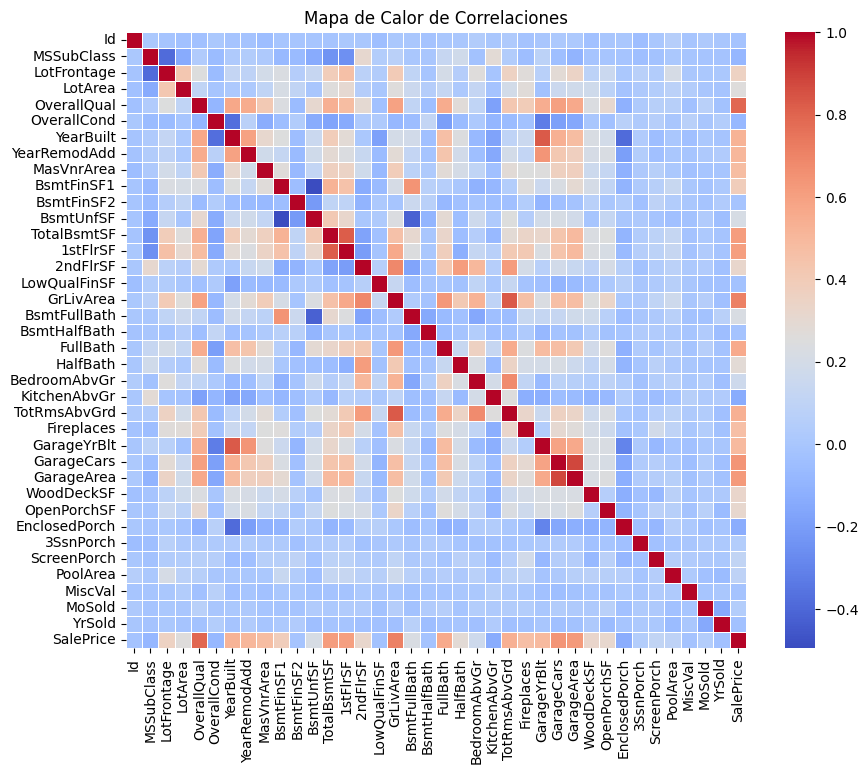

In [9]:
# Crear el mapa de calor de correlaciones
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones')
plt.show()

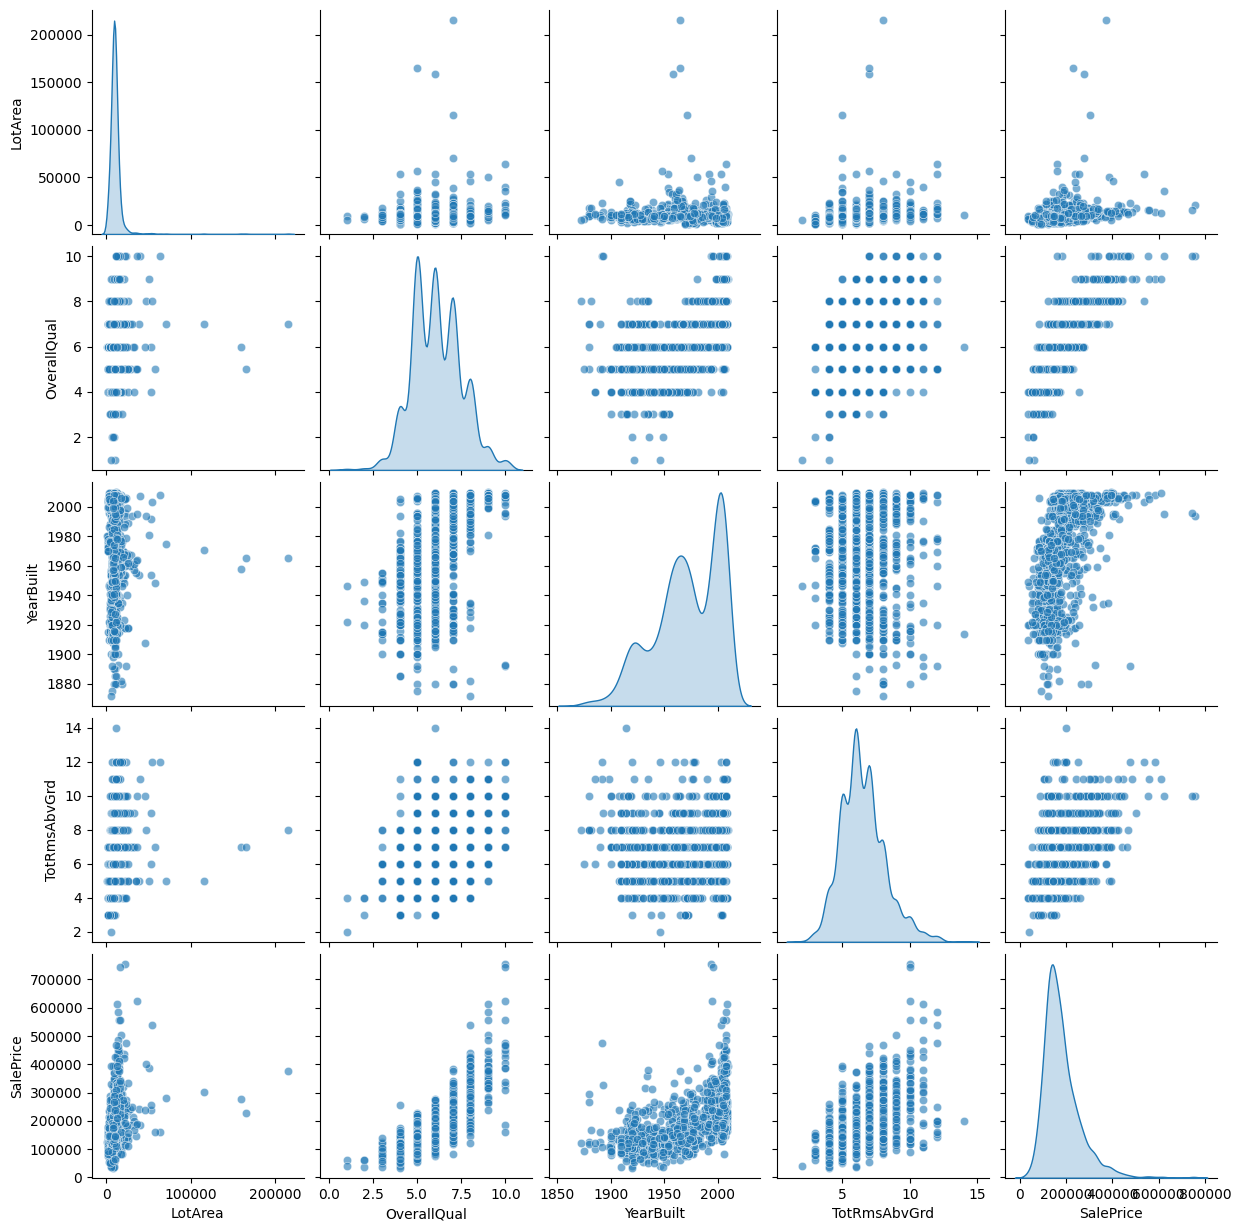

In [10]:
# seleccion un conjunto de variables numericas para graficar el pair plot
df_reducido = df[['LotArea', 'OverallQual', 'YearBuilt', 'TotRmsAbvGrd', 'SalePrice']]


# Crear el pair plot con histogramas en la diagonal
pair_plot = sns.pairplot(df_reducido, diag_kind='kde', plot_kws={'alpha': 0.6})

plt.show()

4. **División de Datos en Conjuntos de Entrenamiento y Prueba**

In [11]:
# Aplicar el preprocesamiento y dividir los datos en conjuntos de entrenamiento y prueba
X = df.drop(columns='SalePrice')  # Eliminar la columna 'SalePrice' de las características
y = df['SalePrice']  # Definir 'SalePrice' como la variable objetivo

# Dividir los datos en conjuntos de entrenamiento y prueba
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Obtener las características numéricas y categóricas de X en lugar de df
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['category', 'object']).columns.tolist()

5. **Pipeline para Procesamiento de Variables**

Como pueden notar aca tratamos los NA encontrados en el numeral 2 de exploración de este notebook.

In [12]:
# Importar la librería necesaria para la imputación de valores faltantes
from sklearn.impute import KNNImputer

# Definir el transformador para las variables numéricas
numeric_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),  # Imputación de valores faltantes usando KNN con 5 vecinos
    ('scaler', StandardScaler())])  # Estandarización de las características numéricas para que tengan media 0 y desviación estándar 1

# Definir el transformador para las variables categóricas
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Imputación de valores faltantes usando la moda (valor más frecuente)
    ('onehot', OneHotEncoder(handle_unknown='ignore',  drop='first'))])  # Codificación One-Hot, ignorando categorías no vistas durante el entrenamiento,

# Combinar los transformadores en un preprocesador con ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),  # Aplicar el transformador numérico a las características numéricas
        ('cat', categorical_transformer, categorical_features)])  # Aplicar el transformador categórico a las características categóricas


In [13]:
# Ajustar y aplicar el preprocesador al conjunto de entrenamiento
# El método fit_transform ajusta el preprocesador a los datos de entrenamiento y luego aplica las transformaciones
X_train_preprocessed = preprocessor.fit_transform(X_train)

# Aplicar el preprocesador al conjunto de prueba
# El método transform aplica las mismas transformaciones ajustadas en el conjunto de entrenamiento a los datos de prueba
X_test_preprocessed = preprocessor.transform(X_test)

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:228: UserWarning: Found unknown categories in columns [14, 29] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [14]:
# Imprimir una muestra del conjunto de entrenamiento preprocesado
# Esto se hace para verificar que las transformaciones del pipeline (imputación, estandarización, codificación, etc.)
print(X_train_preprocessed[:1])

  (0, 0)	-1.1192840216867437
  (0, 1)	-0.8667643047469886
  (0, 2)	-0.060813952372128256
  (0, 3)	-0.21289571021689285
  (0, 4)	-0.8204445578548297
  (0, 5)	0.37221730085603477
  (0, 6)	-0.4554689634533773
  (0, 7)	-1.3460630279925625
  (0, 8)	-0.6011249659381025
  (0, 9)	1.0372686113776926
  (0, 10)	-0.28550406121847727
  (0, 11)	-0.40028164505613256
  (0, 12)	0.5726121928947197
  (0, 13)	0.3742352301895073
  (0, 14)	-0.8019229244046748
  (0, 15)	-0.11899866377895676
  (0, 16)	-0.40709314807972335
  (0, 17)	1.1053195824048596
  (0, 18)	-0.24287002311294137
  (0, 19)	-1.0555657250367967
  (0, 20)	-0.7640975231923183
  (0, 21)	0.13621832007914325
  (0, 22)	-0.2127571124887476
  (0, 23)	-0.9645659090752412
  (0, 24)	-0.9585921495629545
  :	:
  (0, 147)	1.0
  (0, 151)	1.0
  (0, 153)	1.0
  (0, 156)	1.0
  (0, 163)	1.0
  (0, 166)	1.0
  (0, 169)	1.0
  (0, 173)	1.0
  (0, 179)	1.0
  (0, 180)	1.0
  (0, 188)	1.0
  (0, 189)	1.0
  (0, 192)	1.0
  (0, 195)	1.0
  (0, 201)	1.0
  (0, 203)	1.0
  (0, 206)

In [15]:
X_train_preprocessed

<1168x244 sparse matrix of type '<class 'numpy.float64'>'
	with 84934 stored elements in Compressed Sparse Row format>

6. **Evaluación de la Multicolinealidad**

In [16]:
## Obtener los nombres de las características después de la transformación
# Obtener las características numéricas (que no cambian)
numeric_feature_names = numeric_features

# Luego las características generadas por OneHotEncoder para las variables categóricas
categorical_feature_names = list(preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features))

# Combinar todas las características
all_feature_names = numeric_feature_names + categorical_feature_names

# Verificar el número de columnas después de la transformación
print("Forma de X_train_preprocessed:", X_train_preprocessed.shape)
print("Número total de nombres de características:", len(all_feature_names))

# Comprobar si coinciden las dimensiones
if X_train_preprocessed.shape[1] != len(all_feature_names):
    print(f"Error: El número de columnas transformadas ({X_train_preprocessed.shape[1]}) no coincide con los nombres de características ({len(all_feature_names)})")
else:
    print("Las dimensiones coinciden. Procedemos a crear el DataFrame.")

# Si las dimensiones coinciden, crear el DataFrame
if X_train_preprocessed.shape[1] == len(all_feature_names):
    X_train_preprocessed_df = pd.DataFrame(X_train_preprocessed.toarray(), columns=all_feature_names) # Convert to a dense array
    # Convertir X_test_preprocessed en un DataFrame con las columnas correspondientes
    X_test_preprocessed_df = pd.DataFrame(X_test_preprocessed.toarray(), columns=all_feature_names) # Convert to a dense array

    # Ahora extraer solo las columnas numéricas
    X_numeric_transformed = X_train_preprocessed_df[numeric_features]

    # Calcular el VIF para las variables numéricas transformadas
    vif_data = pd.DataFrame()
    vif_data["feature"] = X_numeric_transformed.columns
    vif_data["VIF"] = [variance_inflation_factor(X_numeric_transformed.values, i) for i in range(len(X_numeric_transformed.columns))]

    # Mostrar los resultados del VIF
    print(vif_data)


Forma de X_train_preprocessed: (1168, 244)
Número total de nombres de características: 244
Las dimensiones coinciden. Procedemos a crear el DataFrame.


/usr/local/lib/python3.10/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


          feature       VIF
0              Id  1.034767
1      MSSubClass  1.691988
2     LotFrontage  1.781805
3         LotArea  1.354057
4     OverallQual  3.186138
5     OverallCond  1.578516
6       YearBuilt  5.237747
7    YearRemodAdd  2.403675
8      MasVnrArea  1.411389
9      BsmtFinSF1       inf
10     BsmtFinSF2       inf
11      BsmtUnfSF       inf
12    TotalBsmtSF       inf
13       1stFlrSF       inf
14       2ndFlrSF       inf
15   LowQualFinSF       inf
16      GrLivArea       inf
17   BsmtFullBath  2.200565
18   BsmtHalfBath  1.162617
19       FullBath  2.947531
20       HalfBath  2.112242
21   BedroomAbvGr  2.379130
22   KitchenAbvGr  1.660805
23   TotRmsAbvGrd  5.004572
24     Fireplaces  1.577906
25    GarageYrBlt  3.576550
26     GarageCars  5.519084
27     GarageArea  5.603716
28     WoodDeckSF  1.231846
29    OpenPorchSF  1.230251
30  EnclosedPorch  1.301267
31      3SsnPorch  1.033709
32    ScreenPorch  1.132289
33       PoolArea  1.158251
34        MiscVal  1

Generando pair plot para variables con VIF >= 5 (con colinealidad significativa)...


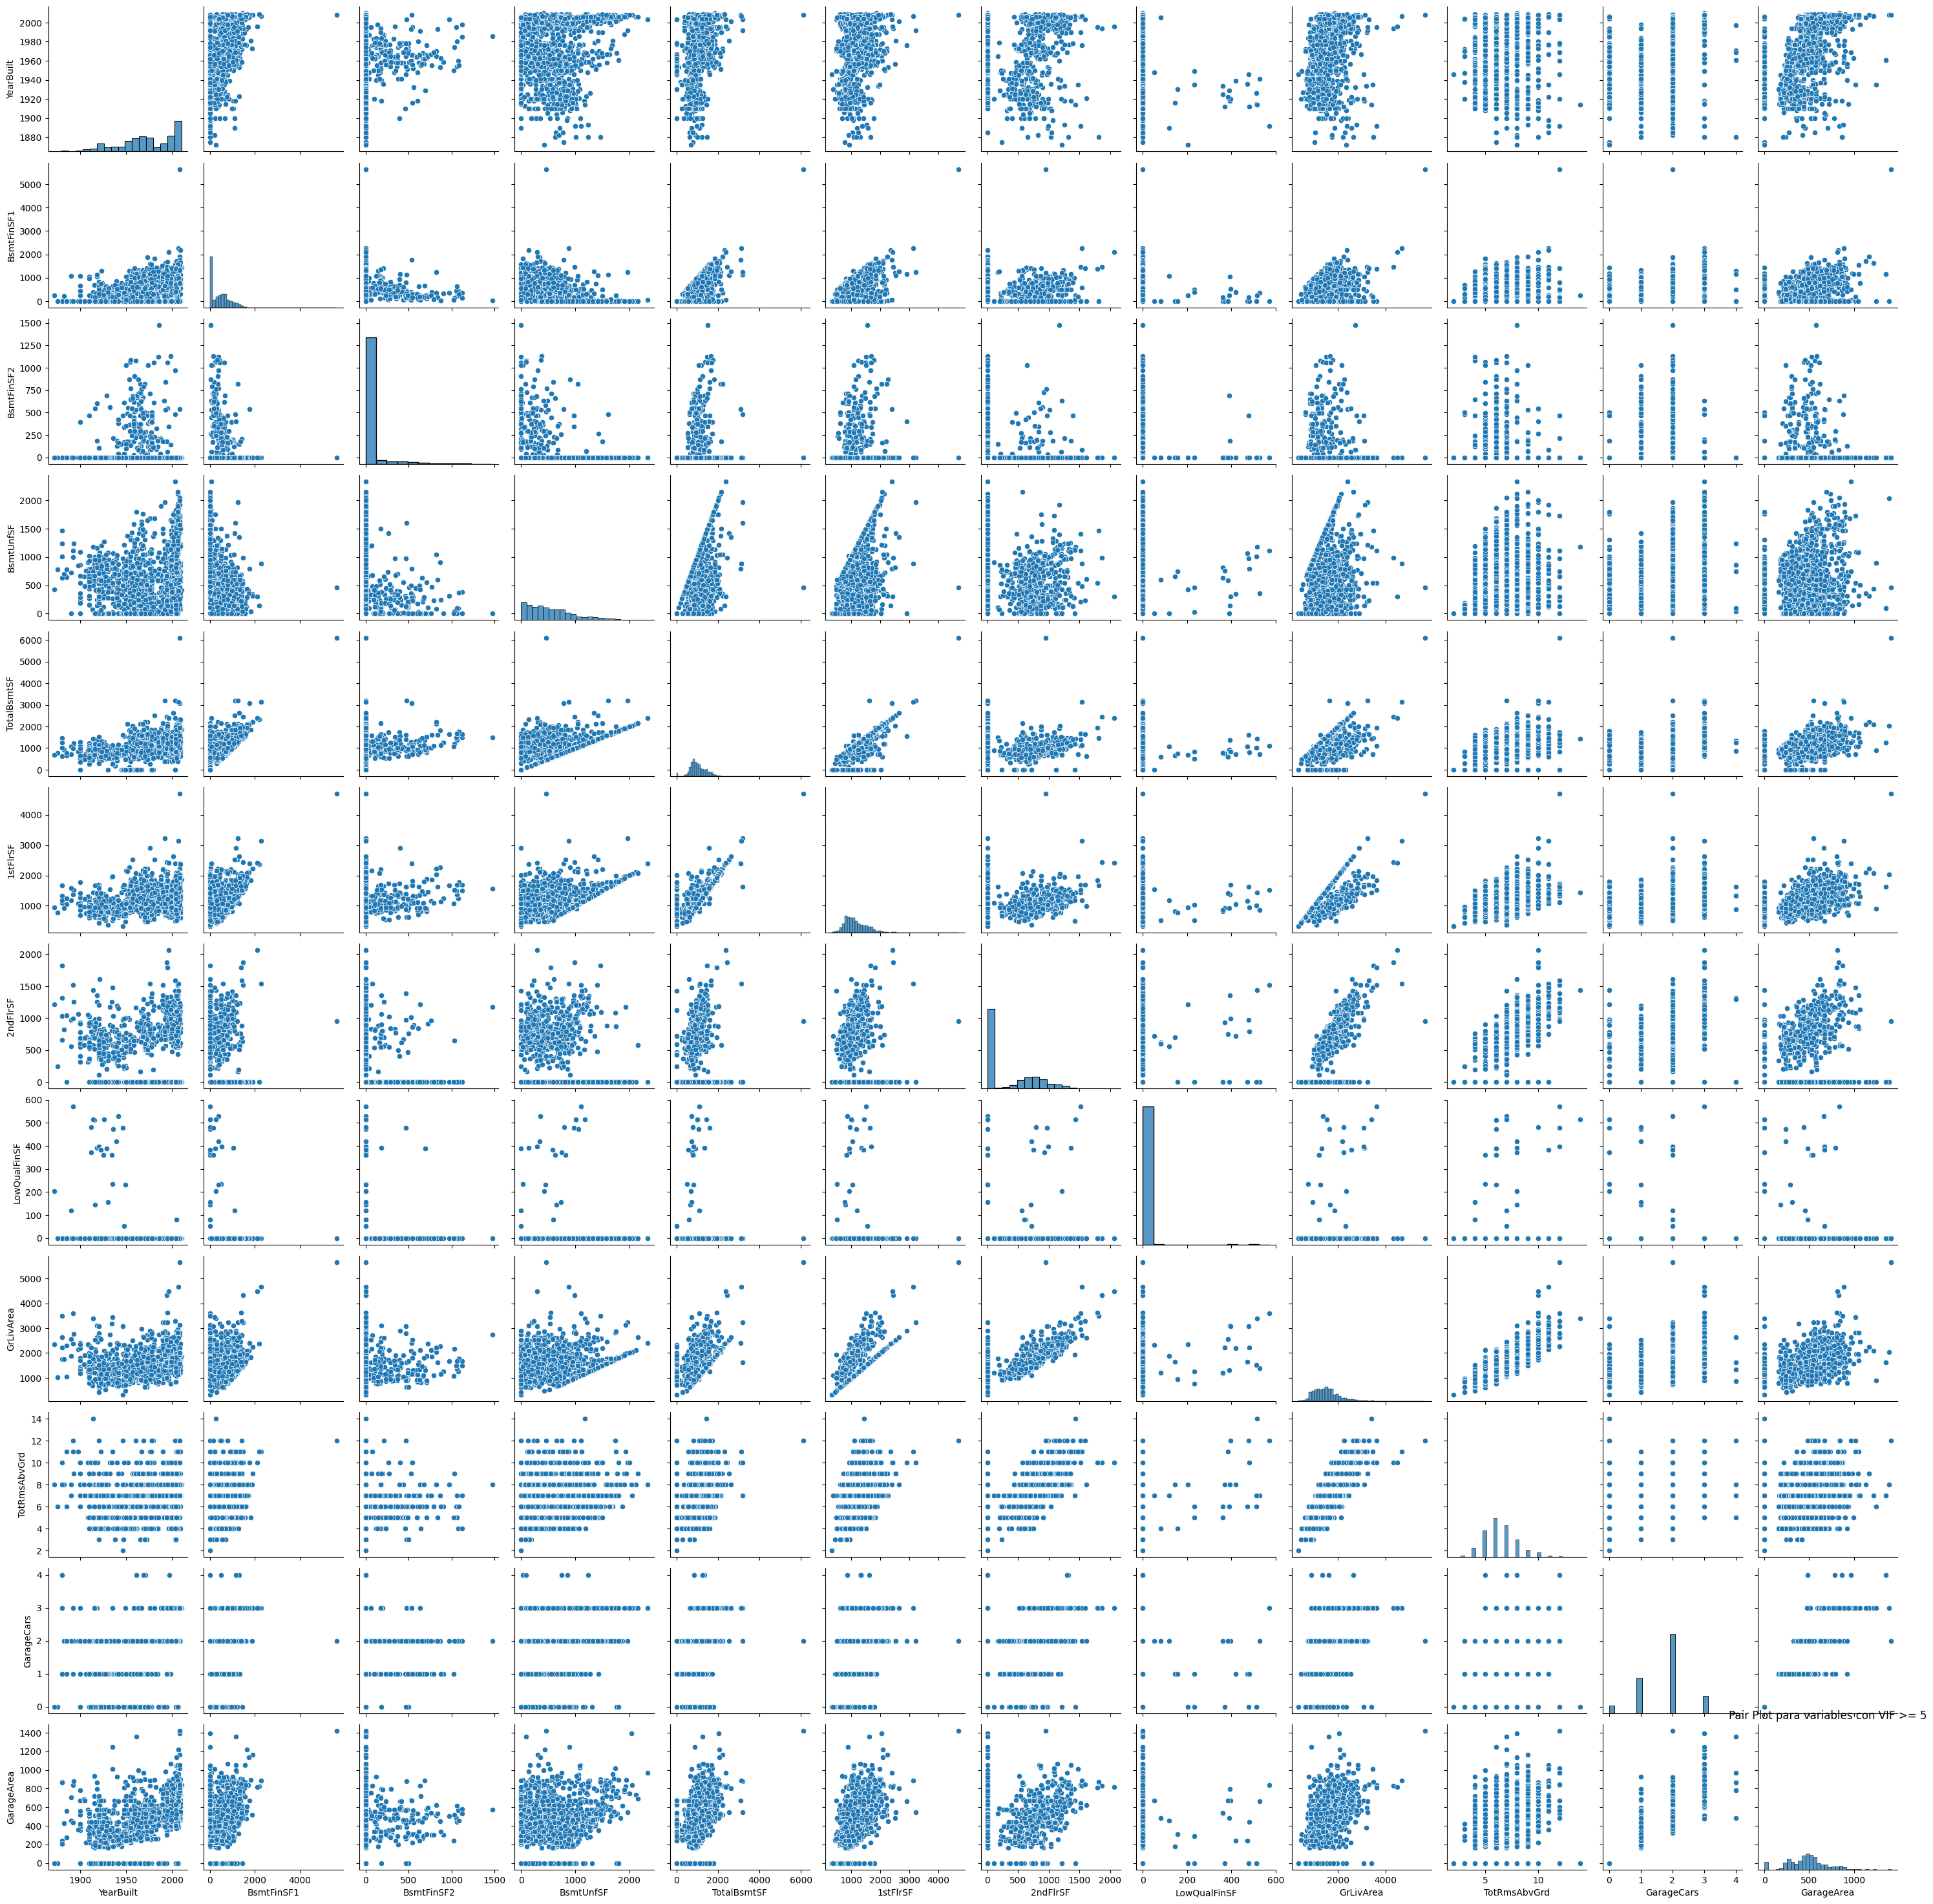

In [17]:
# Definir umbrales de VIF: por ejemplo, VIF > 5 indica colinealidad significativa
high_vif_threshold = 5

# Seleccionar las variables con bajo VIF (sin colinealidad significativa)
low_vif_features = vif_data[vif_data["VIF"] < high_vif_threshold]["feature"].tolist()

# Seleccionar las variables con alto VIF (con colinealidad significativa)
high_vif_features = vif_data[vif_data["VIF"] >= high_vif_threshold]["feature"].tolist()

# Generar el pair plot para las variables con bajo VIF (sin colinealidad)
# print(f"Generando pair plot para variables con VIF < {high_vif_threshold} (sin colinealidad)...")
# sns.pairplot(df[low_vif_features])
# plt.title(f"Pair Plot para variables con VIF < {high_vif_threshold}")
# plt.show()

# Generar el pair plot para las variables con alto VIF (con colinealidad)
print(f"Generando pair plot para variables con VIF >= {high_vif_threshold} (con colinealidad significativa)...")
sns.pairplot(df[high_vif_features])
plt.title(f"Pair Plot para variables con VIF >= {high_vif_threshold}")
plt.show()

In [18]:
low_vif_features

['Id',
 'MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'Fireplaces',
 'GarageYrBlt',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold']

Aqui se deben disminuir las variables, pueden ser las de mayor VF. Si el modelo se corre con todas estas variables se requiere mayor capacidad computacional.

7. **Construcción y Evaluación del Modelo de Regresión Lineal Múltiple**



In [24]:
# Modelos de regresión y selección de características

from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector

lr = LinearRegression()

# Selección hacia adelante (El modelo inicia vacio y se va llenando con las variables de mejor rendimiento)
sfs_forward = SequentialFeatureSelector(lr, n_features_to_select=10, direction='forward')
sfs_forward = sfs_forward.fit(X_train_preprocessed, y_train)

# Selección hacia atrás (El modelo inicia lleno y se van eliminando las de menor contribución)
# sfs_backward = SequentialFeatureSelector(lr, n_features_to_select=10, direction='backward')
# sfs_backward.fit(X_train_preprocessed, y_train)

# Evaluar los modelos

selected_features_forward = sfs_forward.get_support()
# selected_features_backward = sfs_backward.get_support()

# Ajustar el modelo nuevamente solo con las características seleccionadas
lr.fit(X_train_preprocessed[:, selected_features_forward], y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_forward = lr.predict(X_test_preprocessed[:, selected_features_forward])

# lr.fit(X_train_preprocessed[:, selected_features_backward], y_train)
# y_pred_backward = lr.predict(X_test_preprocessed[:, selected_features_backward])

# Métricas de evaluación
from sklearn.metrics import r2_score
print("Forward Selection: R2:", r2_score(y_test, y_pred_forward))
#print("Backward Selection: R2:", r2_score(y_test, y_pred_backward))

Forward Selection: R2: 0.8293010949260355


## 4. Regresión Polinómica

La regresión polinómica es una extensión de la regresión lineal que permite
modelar relaciones no lineales. Util cuando la relación entre la variable dependiente y las independientes no es
lineal.

In [25]:
#  Añadir términos polinómicos e interacciones
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train_preprocessed)
X_test_poly = poly.transform(X_test_preprocessed)

# Entrenar el modelo polinómico
lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)

# Predicciones y evaluación del modelo polinómico
y_pred_poly = lr_poly.predict(X_test_poly)
print("Polynomial Model: R2:", r2_score(y_test, y_pred_poly))



Polynomial Model: R2: 0.8557126490386919


9. **Evaluación de Supuestos del Modelo**

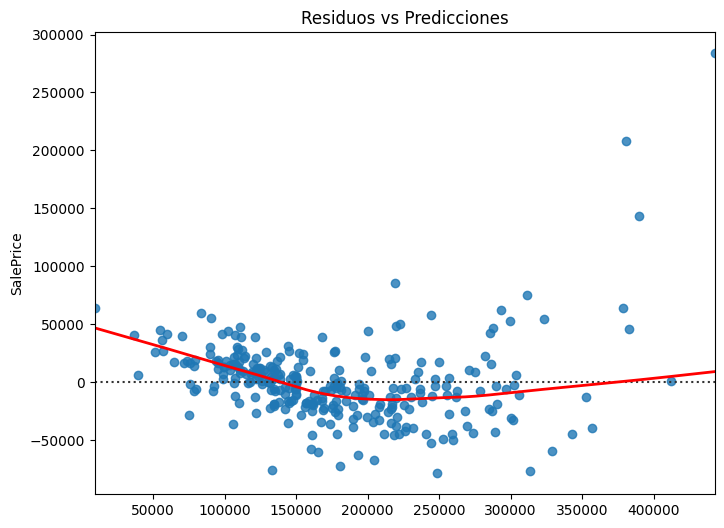

Estadística de Durbin-Watson: 1.8823830701179953


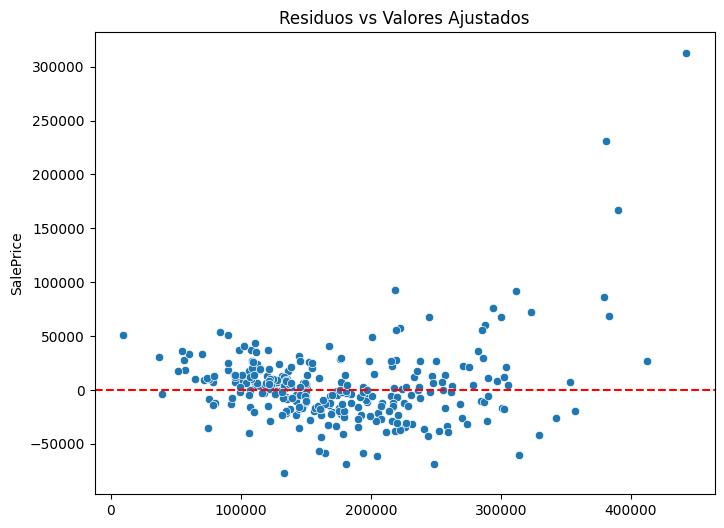

<Figure size 800x600 with 0 Axes>

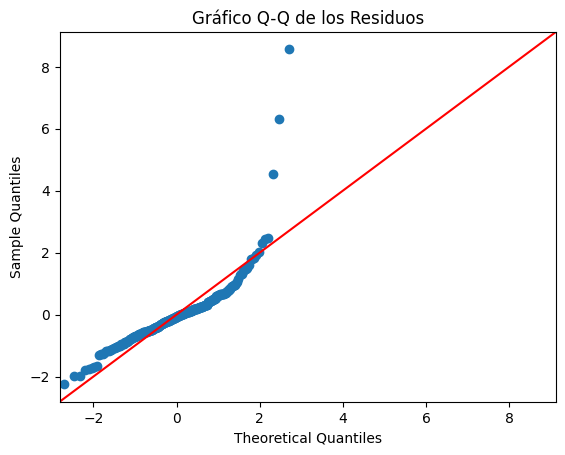

Prueba de Shapiro-Wilk: Estadística = 0.7670080730987274, p-valor = 4.610732139438914e-20


In [31]:
# Evaluación de supuestos del modelo (LINE- Forward Selection)

# Residuos del modelo
residuals = y_test - y_pred_forward

# Verificación de linealidad: gráfico de residuos vs predicciones
plt.figure(figsize=(8, 6))
sns.residplot(x=y_pred_forward, y=residuals, lowess=True, line_kws={'color': 'red', 'lw': 2})
plt.title('Residuos vs Predicciones')
plt.show()

# Cálculo y muestra del estadístico Durbin-Watson para la independencia de los errores
dw_statistic = durbin_watson(residuals)
print(f'Estadística de Durbin-Watson: {dw_statistic}')

# Verificación de homocedasticidad
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred_forward, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuos vs Valores Ajustados')
plt.show()

# Verificación de normalidad: Q-Q Plot
plt.figure(figsize=(8, 6))
sm.qqplot(residuals, line='45', fit=True)
plt.title('Gráfico Q-Q de los Residuos')
plt.show()

# Cálculo y muestra del resultado de la prueba de Shapiro-Wilk para normalidad
shapiro_test = stats.shapiro(residuals)
print(f'Prueba de Shapiro-Wilk: Estadística = {shapiro_test[0]}, p-valor = {shapiro_test[1]}')



Si los resultados de la Prueba de Durbin-Watson están cerca de 2, los residuos son independientes.

Un gráfico de residuos vs. valores ajustados sin patrones claros indica homocedasticidad.

Un Q-Q Plot con puntos cercanos a la línea de referencia también sugiere normalidad en los residuos.

Si las Pruebas de Shapiro-Wilk tiene p-valores mayores a 0.05, los residuos probablemente siguen una distribución normal.

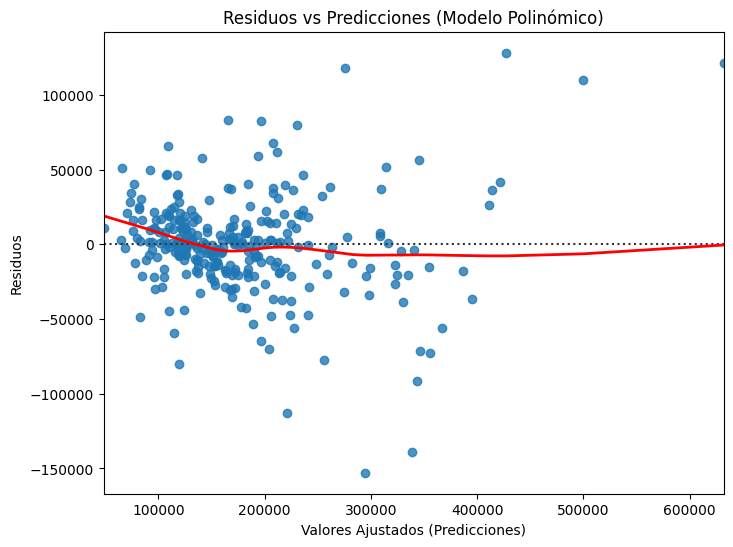

Estadística de Durbin-Watson (Modelo Polinómico): 2.0135119997182227


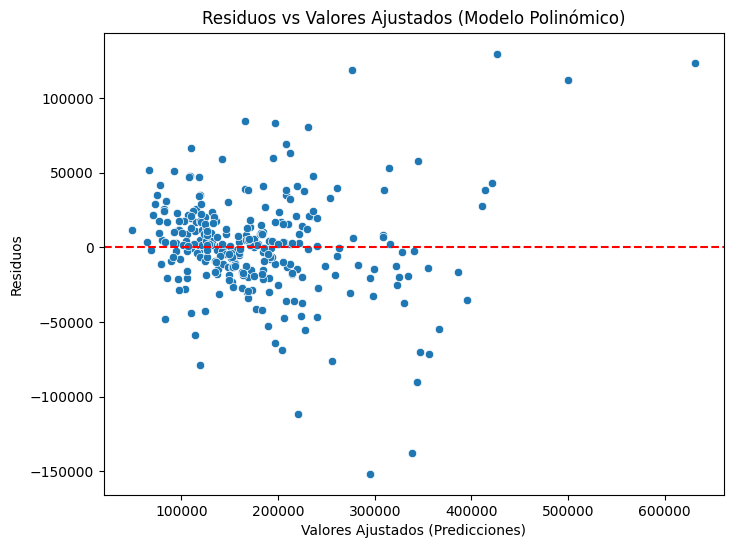

<Figure size 800x600 with 0 Axes>

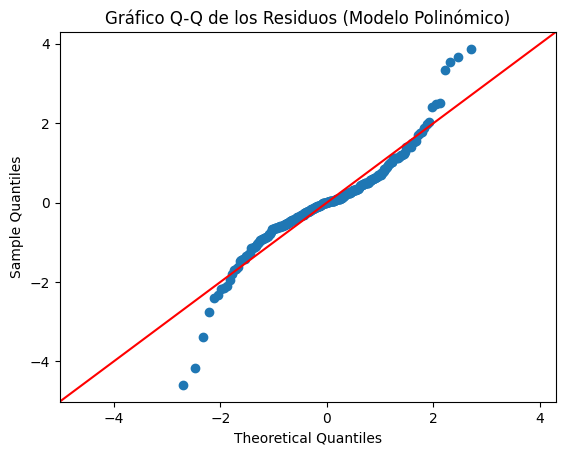

Prueba de Shapiro-Wilk (Modelo Polinómico): Estadística = 0.9268915372834899, p-valor = 8.820338044069752e-11


In [32]:
# Evaluación de supuestos del modelo (Regresión Polinómica)

# Residuos del modelo polinómico
residuals_poly = y_test - y_pred_poly

# Verificación de linealidad: gráfico de residuos vs predicciones
plt.figure(figsize=(8, 6))
sns.residplot(x=y_pred_poly, y=residuals_poly, lowess=True, line_kws={'color': 'red', 'lw': 2})
plt.title('Residuos vs Predicciones (Modelo Polinómico)')
plt.xlabel('Valores Ajustados (Predicciones)')
plt.ylabel('Residuos')
plt.show()

# Cálculo y muestra del estadístico Durbin-Watson para la independencia de los errores
dw_statistic_poly = durbin_watson(residuals_poly)
print(f'Estadística de Durbin-Watson (Modelo Polinómico): {dw_statistic_poly}')

# Verificación de homocedasticidad: gráfico de residuos vs valores ajustados
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred_poly, y=residuals_poly)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuos vs Valores Ajustados (Modelo Polinómico)')
plt.xlabel('Valores Ajustados (Predicciones)')
plt.ylabel('Residuos')
plt.show()

# Verificación de normalidad: Q-Q Plot
plt.figure(figsize=(8, 6))
sm.qqplot(residuals_poly, line='45', fit=True)
plt.title('Gráfico Q-Q de los Residuos (Modelo Polinómico)')
plt.show()

# Cálculo y muestra del resultado de la prueba de Shapiro-Wilk para normalidad
shapiro_test_poly = stats.shapiro(residuals_poly)
print(f'Prueba de Shapiro-Wilk (Modelo Polinómico): Estadística = {shapiro_test_poly[0]}, p-valor = {shapiro_test_poly[1]}')



A continuación se presenta otra funcion estadistica para evaluar la homocedasticidad en este caso solo se utiliza el del modelo de regresión lineal multiple para ejemplificar dado que ya se comprobaron los supuestas de ambos modelos.

In [33]:
# Prueba de Levene para homocedasticidad
statistic, p_value = stats.levene(residuals, residuals_poly)
print(f'Prueba de Levene: Estadística = {statistic}, p-value = {p_value}')


Prueba de Levene: Estadística = 0.025315951979564603, p-value = 0.8736375065683555


Hipótesis Nula (H₀): Las varianzas de los residuos son iguales para todos los grupos de predicciones. Es decir, los residuos son homocedásticos.
Hipótesis Alternativa (H₁): Las varianzas de los residuos no son iguales para todos los grupos de predicciones. Es decir, los residuos son heterocedásticos.

p-valor: El p-valor obtenido es 0.8736, que es mucho mayor que el umbral comúnmente utilizado de 0.05. Este valor alto del p-valor significa que no hay suficiente evidencia para rechazar la hipótesis nula de que las varianzas son iguales.

10. **Comparación del Rendimiento de los Modelos**

In [34]:
# Comparación de modelos
print(f'Forward Selection R2: {r2_score(y_test, y_pred_forward)}')
# print(f'Backward Selection R2: {r2_score(y_test, y_pred_backward)}')
print(f'Polynomial Model R2: {r2_score(y_test, y_pred_poly)}')

Forward Selection R2: 0.8293010949260355
Polynomial Model R2: 0.8557126490386919


In [35]:
# Número de observaciones y número de parámetros para cada modelo
n = len(y_test)

# Para el modelo de regresión lineal (Forward Selection)
p_forward = X_train.shape[1] + 1  # Número de parámetros en el modelo de selección hacia adelante (incluyendo el intercepto)
rss_forward = np.sum(residuals**2)  # Suma de los cuadrados de los residuos
mse_forward = rss_forward / n  # Error cuadrático medio (MSE)

# Cálculo de AIC y BIC para el modelo lineal (Forward Selection)
aic_forward = n * np.log(mse_forward) + 2 * p_forward
bic_forward = n * np.log(mse_forward) + p_forward * np.log(n)


print(f"AIC (Modelo Lineal - Forward Selection): {aic_forward}")
print(f"BIC (Modelo Lineal - Forward Selection): {bic_forward}")


# Para el modelo de regresión polinómica
p_poly = X_train_poly.shape[1] + 1  # Número de parámetros en el modelo polinómico (incluyendo el intercepto)
rss_poly = np.sum(residuals_poly**2)  # Suma de los cuadrados de los residuos
mse_poly = rss_poly / n  # Error cuadrático medio (MSE)

# Cálculo de AIC y BIC para el modelo polinómico
aic_poly = n * np.log(mse_poly) + 2 * p_poly
bic_poly = n * np.log(mse_poly) + p_poly * np.log(n)


print(f"AIC (Modelo Polinómico): {aic_poly}")
print(f"BIC (Modelo Polinómico): {bic_poly}")



AIC (Modelo Lineal - Forward Selection): 6291.8891081031725
BIC (Modelo Lineal - Forward Selection): 6589.706166086903
AIC (Modelo Polinómico): 65862.80553996313
BIC (Modelo Polinómico): 175764.65344356434


## Referencias

**Texto guía**
- Notas de clase del curso (disponibles en el repositorio).

**Bibliografía complementaria**
- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2023). *An Introduction to Statistical Learning with Applications in Python* (Cap. 3). Springer.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (Cap. 3). Springer.
- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed., Cap. 4). O'Reilly Media.